# An Investigation of Volatility Drag

### Introduction

In mathematical finance, volatility drag describes the effect of large, downward variances in asset returns on a portfolio's long-term geometric returns. This elusive phenomenon affirms that, regarding arithmetic returns, negative returns have an asymetric effect on long-term wealth when compared to positive returns. Consider a portfolio of $\$100$: a $50\%$ loss in value, followed by an increase of $50\%$ would produce an average return of $0\%$, meaning we broke even. This is false, as our portfolio value would fall to $\$50$, then rise to a mere $\$75$ ($50\%$ increase of $\$50$), leading to a net loss of $25\%$ in value.

This disagreement motivates the use of geometric returns, or log returns, to tell the full story. If we consider the same portfolio of $\$100$, when the price drops to $\$50$, we use: $$\ln(\frac{P_{Final}}{P_{Initial}}) = \ln(\frac{50}{100}) = -69.3\%$$ then when the price rises to $\$75$: $$\ln(\frac{75}{50}) = +40.5\%$$ which sums to a more accurate loss of approximately $28.8\%$.

In real life, the difference between the geometric and arithmetic returns of an asset or portfolio is much smaller, but it still exist. This naturally raises the question: what explains this difference?

### Derivation

Deriving the quantitative coefficient of volatility drag is somewhat technical, but that's what makes it fun!

To begin, let $V_N$ be the value of an asset or portfolio after N periods.
$$V_N = (1+r_1)(1+r_2)...(1+r_N)$$
or
$$V_N = \prod_{i=1}^{N}(1+r_i)$$

Next, we come up with $R_g$ that is equivalent to all $r_i$
$$\prod_{i=1}^{N}(1+R_g)$$
which can be written simply as
$$(1+R_g)^N$$

Now we are left with
$$(1+R_g)^N = \prod_{i=1}^{N}(1+r_i)$$
Taking the natural log of both sides, to convert products to sums, gives
$$\ln((1+R_g)^N) = \ln(\prod_{i=1}^{N}(1+r_i))$$
and using basic log properties
$$N\ln(1+R_g) = \sum_{i=1}^{N} \ln(1+r_i)$$


Next we use the taylor series expansion of $\ln(1+x)$,
$$x-\frac{x^2}{2}+\frac{x^3}{3}-...$$
But, including an infinite series in our equation will not help us much. It is sufficient to say that $$\ln(1+x) \approx x-\frac{x^2}{2}$$ since returns $|x| << 1$, and higher powers of $x$ will be indifferent from $0$, especially from a machine precision standpoint.

Now, using this result on the LHS and RHS will yield
$$R_g-\frac{R_g^2}{2} \approx \frac{1}{N} \sum_{i=1}^{N} (r_i - \frac{r_i^2}{2})$$

Next, we distibute the sum to both terms on the RHS
$$R_g-\frac{R_g^2}{2} \approx \frac{1}{N} \sum_{i=1}^{N} r_i - \frac{1}{2N} \sum_{i=1}^{N}r_i^2$$

If we notice that $\frac{1}{N} \sum_{i=1}^{N} r_i$ is simply the arithmetic mean of all $r_i$, or $\bar{r}$, 

then
$$R_g-\frac{R_g^2}{2} \approx \bar{r} - \frac{1}{2N} \sum_{i=1}^{N}r_i^2$$


To simplify the rightmost term, we need to use variance, given by
$$\sigma^2 = \frac{1}{N} \sum_{i=1}^{N}(r_i - \bar{r})^2$$
Expanding $(r_i - \bar{r})^2$ gives
$$\sigma^2 = \frac{1}{N} \sum_{i=1}^{N}(r_i^2 - 2r_i\bar{r} + \bar{r}^2)$$

Next, we distribute the sum.
$$\sigma^2 = \frac{1}{N} \sum_{i=1}^{N}r_i^2 - \frac{1}{N} \sum_{i=1}^{N}2r_i\bar{r} + \frac{1}{N} \sum_{i=1}^{N}\bar{r}^2$$
$$\sigma^2 = \frac{1}{N} \sum_{i=1}^{N}r_i^2 - 2\bar{r}(\frac{1}{N} \sum_{i=1}^{N}r_i) + \frac{1}{N} (N\bar{r}^2)$$
$$\sigma^2 = \frac{1}{N} \sum_{i=1}^{N}r_i^2 - 2\bar{r}^2 + \bar{r}^2$$
$$\sigma^2 + \bar{r}^2 = \frac{1}{N} \sum_{i=1}^{N}r_i^2  $$

Now, substituting this result will yield
$$R_g-\frac{R_g^2}{2} \approx \bar{r} - \frac{1}{2}(\sigma^2 + \bar{r}^2)$$

and solving for $R_g$ gives
$$R_g \approx \bar{r} - \frac{\sigma^2}{2} - \frac{\bar{r}^2}{2} + \frac{R_g^2}{2}$$

Then, since $\bar{r} \approx R_g$, and $|\bar{r}|, |R_g| << 1$, squaring these terms and taking the difference will yield a number indistinguishable from zero. Therefore, we are left with
$$R_g \approx \bar{r} - \frac{\sigma^2}{2}$$
or
$$R_g \approx \mu - \frac{\sigma^2}{2}$$

Where:
- $R_g$ is the geometric mean return,
- $\mu$ is the arithmetic mean return, and
- $\frac{\sigma^2}{2}$ is volatility drag.

This result has numerous implications for investors:
- First and most importantly, we can see mathematically that as volatility increases, geometric returns decrease. For every downward swing in price, it must rise more to break even.
- Second, we can observe its non-linear effect on geometric returns. Volatility drag scales with the square of volatility, meaning volatility erodes gains disproportionately.
- Third, a higher volatility in the market implies higher potential drawdowns, meaning if we need to sell assets during a crisis, we selling for a massive loss.
- Finally, the psychological factor of expiriencing massive drawdowns is very real. Panic-selling assets during a crisis will also realize huge losses.

The mathematical, liquidity, and psychology related factors at play in the market are all against volatility. When our goal is to make it to the long-term so we can experience the beauty of compounding, reducing volatility helps us get there. 

### Methods of Reducing Volatility

#### Diversification and Why It Fails
Almost instinctively, when seeking to reduce volatility in a portfolio, we resort to the *diversification* of assets. Allocating capital across multiple companies and sectors helps reduce *idiosyncratic risk* (company specific) and *sector risk*, but there is another layer of risk we are subject to: *market risk*.
During periods of high liquidity or market distress, while we have diversified away the first two forms of risk, the *market risk* takes precedence and all assets become highly correlated, leading to massive drawdowns and high volatility. 

#### Hedging vs. Diversification
Where *diversification* fails, and *hedging* becomes key. While the two terms appear to be synonymous, we have already exposed their distinction. *Diversification* involves investing across multiple uncorrelated assets (which we know fails when we need it most). *Hedging* involves investing in completely orthogonal assets, and those which are negatively correlated, to protect against market drawdowns. Think of, for example, the returns generated by the S&P 500 and prediction market making; they have nothing to do with each other. If the S&P 500 experiences a massive drawdown, the other leg of our portfolio will be unaffected, helping reduce the overall volatility our portfolio experiences. In short, *diversification* protects against unsystematic risks, while *hedging* acts as insurance for systematic *market risk*.

#### Effective Hedging 
To find assets who provide returns orthogonal to each other, we must prove their independence. A pearson correlation matrix

This dynamic illustrates the difference between *physical* and *stochastic* independence. Stochastically independent assets are assets who's returns are statistically independent (produce a correlation near 0). As we've discussed above, *stochastically independent* assets may seem to provide diversification, but ultimately fail to do so when we need it most. This motivates the more robust *physical independence*, meaning that the returns for assets are completely orthogonal to one another throughout all market regimes. 

This type of independence help us achieve *structural diversification*, helping mitigate the elusive *market risk* and produce more stable returns.

#### structural diversification definition
*Structural diversification* occurs when the underlying mechanisms driving return streams are orthogonal to one another. 
 

    use of derivatives for structural hedging

### Compare Strategy to S&P 500

[*********************100%***********************]  2 of 2 completed

== Max Drawdown ==
SPY: -33.72%
Active Hedge Strategy: -21.35%
Passive Hedge Strategy: -20.44%

== Annualized Arithmetic Returns ==
SPY: 15.57%
Active Hedge Strategy: 12.08%
Passive Hedge Strategy: 9.02%

== Annualized Sharpe Ratio ==
SPY: 0.77
Active Hedge Strategy: 0.93
Passive Hedge Strategy: 0.72


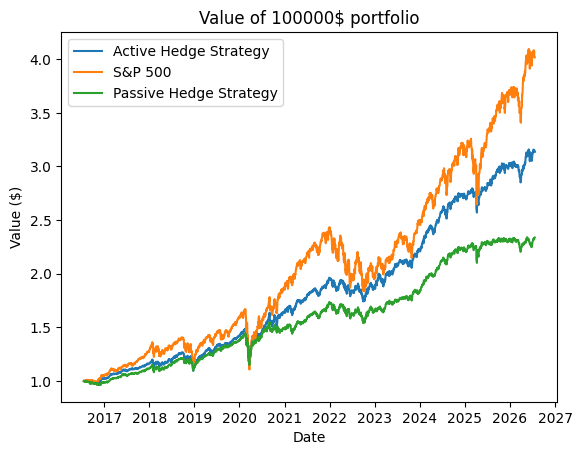

In [64]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# parameters
starting_capital = 100000
fast_window = 50
slow_window = 150

# get data
tickers = ["SPY", # S&P 500
           "BTAL" # U.S. Anti-Beta Fund; long low-vol, short high-vol
          ]
df = yf.download(tickers, period="10y")["Close"].dropna()

df["SPY Returns"] = df["SPY"].pct_change().dropna()


# Strategy
# calculate SMAs
df["fast SMA"] = df["SPY"].rolling(fast_window).mean()
df["slow SMA"] = df["SPY"].rolling(slow_window).mean()

# crossover signal
df["Crossover"] = ((df["fast SMA"] > df["slow SMA"]) & (df["fast SMA"].shift(1) <= df["slow SMA"].shift(1))).astype(int)

# running day count since crossover
df["Days Since Crossover"] = df.groupby(df["Crossover"].cumsum()).cumcount()

# find number of periods to rebalance
df["Periods"] = df["Days Since Crossover"] // 25

df.loc[df["Periods"] > 10, "Periods"] = 10

# calculate running weights
df["SPY Weight"] = 0.9 - (df["Periods"] * 0.025)
df["BTAL Weight"] = 1 - df["SPY Weight"]

# find portfolio returns
df["Active Strategy Returns"] = ( df["SPY"].pct_change() * df["SPY Weight"].shift(1) + # shift to avoid lookahead bias
                            df["BTAL"].pct_change() * df["BTAL Weight"].shift(1)
                          )
df["Passive Strategy Returns"] = ( df["SPY"].pct_change() * 0.65 + 
                 df["BTAL"].pct_change() * 0.35
               )

# portfolio values
active = (1 + df["Active Strategy Returns"]).cumprod()
spy = (1 + df["SPY Returns"]).cumprod()
passive = (1 + df["Passive Strategy Returns"]).cumprod()


# Metrics
# max drawdown
spy_running = df["SPY"].cummax()
spy_dd = (df["SPY"] - spy_running) / spy_running
spy_maxdd = np.min(spy_dd)

active_running = active.cummax()
active_dd = (active - active_running) / active_running
active_maxdd = np.min(active_dd)

passive_running = passive.cummax()
passive_dd = (passive - passive_running) / passive_running
passive_maxdd = np.min(passive_dd)

# annualized returns
active_annualized_returns = df["Active Strategy Returns"].mean() * 252
spy_annualized_returns = df["SPY Returns"].mean() * 252
passive_annualized_returns = df["Passive Strategy Returns"].mean() * 252

# annualized risk
active_annualized_risk = df["Active Strategy Returns"].std() * np.sqrt(252)
spy_annualized_risk = df["SPY Returns"].std() * np.sqrt(252)
passive_annualized_risk = df["Passive Strategy Returns"].std() * np.sqrt(252)

# sharpe ratio
rf = 0.0184 # 10y T-Bill Rate in 2016, U.S.
active_sharpe = (active_annualized_returns - rf) / active_annualized_risk
spy_sharpe = (spy_annualized_returns - rf) / spy_annualized_risk
passive_sharpe = (passive_annualized_returns - rf) / passive_annualized_risk


print("== Max Drawdown ==")
print(f"SPY: {spy_maxdd:.2%}")
print(f"Active Hedge Strategy: {active_maxdd:.2%}")
print(f"Passive Hedge Strategy: {passive_maxdd:.2%}")

print()

print("== Annualized Arithmetic Returns ==")
print(f"SPY: {spy_annualized_returns:.2%}")
print(f"Active Hedge Strategy: {active_annualized_returns:.2%}")
print(f"Passive Hedge Strategy: {passive_annualized_returns:.2%}")

print()

print("== Annualized Sharpe Ratio ==")
print(f"SPY: {spy_sharpe:.2f}")
print(f"Active Hedge Strategy: {active_sharpe:.2f}")
print(f"Passive Hedge Strategy: {passive_sharpe:.2f}")


# plot
plt.plot(active, label="Active Hedge Strategy")
plt.plot(spy, label="S&P 500")
plt.plot(passive, label="Passive Hedge Strategy")

plt.title(f"Value of {starting_capital}$ portfolio")
plt.xlabel("Date")
plt.ylabel("Value ($)")

plt.legend()

# CAPM Regression

In finance, the Capital Asset Pricing Model (CAPM)

[*********************100%***********************]  1 of 1 completed

const    0.000081
x1       0.568167
dtype: float64
const    0.000007
x2       0.474994
dtype: float64


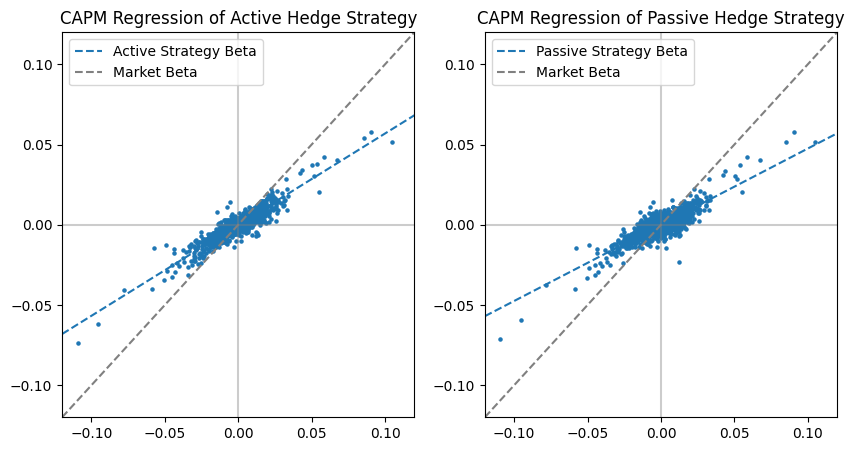

In [54]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.api as sm


# get 10y t-bill data
df["Tbill"] = yf.download("^TNX", period="10y")["Close"] / 100 / 252 # for daily returns

# CAPM Regression
# active stategy
df["x1"] = df["SPY Returns"] -  df["Tbill"] # Rm - Rf
df["y1"] = df["Active Strategy Returns"] - df["Tbill"] # Ri - Rm

regression_data = df[["y1", "x1"]].dropna()

y1_clean = regression_data["y1"]
x1_clean = sm.add_constant(regression_data["x1"]) # so intercept isn't forced to be 0

active_strat_model = sm.OLS(y1_clean, x1_clean).fit()
print(active_strat_model.params)


# passive strategy
df["x2"] = df["SPY Returns"] -  df["Tbill"] # Rm - Rf
df["y2"] = df["Passive Strategy Returns"] - df["Tbill"] # Ri - Rm

regression_data = df[["y2", "x2"]].dropna()

y2_clean = regression_data["y2"]
x2_clean = sm.add_constant(regression_data["x2"]) # so intercept isn't forced to be 0

passive_strat_model = sm.OLS(y2_clean, x2_clean).fit()
print(passive_strat_model.params)


# create regression lines
x = np.linspace(-.12, 0.12, 100)
y = x

line1 = active_beta*x + active_alpha
line2 = passive_beta*x + passive_alpha

# metrics
active_alpha = active_strat_model.params.iloc[0]
active_beta = active_strat_model.params.iloc[1]

passive_alpha = passive_strat_model.params.iloc[0]
passive_beta = passive_strat_model.params.iloc[1]


# plot

fig, ax = plt.subplots(1, 2, figsize=(10,5))

ax[0].scatter(df["SPY Returns"].dropna(), df["Active Strategy Returns"].dropna(),  s=5)
ax[1].scatter(df["SPY Returns"].dropna(), df["Passive Strategy Returns"].dropna(), s=5)

ax[0].set_xlim(-0.12, 0.12)
ax[0].set_ylim(-0.12, 0.12)
ax[1].set_xlim(-0.12, 0.12)
ax[1].set_ylim(-0.12, 0.12)

ax[0].plot(x, line1, "--", label="Active Strategy Beta")
ax[0].plot(x, y, color="grey", linestyle="--", label="Market Beta")
ax[0].axhline(0, color="grey", alpha=0.4)
ax[0].axvline(0, color="grey", alpha=0.4)

ax[1].plot(x, line2, "--", label="Passive Strategy Beta")
ax[1].plot(x, y, color="grey", linestyle="--", label="Market Beta")
ax[1].axhline(0, color="grey", alpha=0.4)
ax[1].axvline(0, color="grey", alpha=0.4)


ax[0].set_title("CAPM Regression of Active Hedge Strategy")
ax[1].set_title("CAPM Regression of Passive Hedge Strategy")

ax[0].legend()
ax[1].legend()






### Conclusion